# cw_odmr_lock_in result: scan1-scan8

First runs taken after fixing the AWG CH1 issue (see `notes.md`'s SR830 section -- `*RST` was silently resetting CH1's continuous carrier off on every connection; `setup_ch1_carrier()` now re-configures it every run) -- from `D:\cw_odmr_lock_in\scan{1..8}`. These are the first valid runs showing the real dip.

Some points read as saturated (a value hit some level and stayed there for several consecutive frequency points -- an ADC/sensitivity clipping signature, not real signal, since real noise essentially never repeats bit-for-bit). `find_saturated_mask()` below flags these; they're plotted grayed out rather than dropped, so you can see where/how much of each scan is affected.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"D:\cw_odmr_lock_in"
RUN_NAMES = ["scan1", "scan2", "scan3", "scan4", "scan5", "scan6", "scan7", "scan8"]

runs = {}
for name in RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    reflected_dbm = np.load(f"{run_path}/{name}_lockin_spectrum_reflected_dbm.npy")
    freqs_ghz = freqs_hz / 1e9
    runs[name] = dict(freqs_ghz=freqs_ghz, x=x, y=y, r=np.hypot(x, y),
                       reflected_dbm=reflected_dbm)
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_ghz.min():.6f}-{freqs_ghz.max():.6f} GHz")

scan1: 137 points, 2.860250-2.873850 GHz


scan2: 130 points, 2.859750-2.872650 GHz
scan3: 133 points, 2.860725-2.873925 GHz


scan4: 116 points, 2.865825-2.877325 GHz
scan5: 136 points, 2.444725-2.458225 GHz


scan6: 129 points, 2.832600-2.845400 GHz


scan7: 123 points, 2.839600-2.851800 GHz
scan8: 122 points, 2.851450-2.863550 GHz


## Saturation detection

In [2]:
def find_saturated_mask(values, min_run=3):
    """
    Flag points that are part of a run of >= min_run consecutive
    (near-)identical values -- a stuck/saturated reading (ADC or
    sensitivity-range clipping), not real signal or noise: real noise
    essentially never repeats bit-for-bit for that many points in a row.
    Returns a boolean array, True where a point belongs to such a run.
    """
    values = np.asarray(values)
    n = len(values)
    mask = np.zeros(n, dtype=bool)
    if n == 0:
        return mask
    run_start = 0
    for i in range(1, n):
        if not np.isclose(values[i], values[i - 1], rtol=1e-9, atol=0):
            if i - run_start >= min_run:
                mask[run_start:i] = True
            run_start = i
    if n - run_start >= min_run:
        mask[run_start:] = True
    return mask


for name in RUN_NAMES:
    sat = find_saturated_mask(runs[name]["x"])
    runs[name]["saturated"] = sat
    print(f"{name}: {sat.sum()}/{len(sat)} points flagged saturated")

scan1: 0/137 points flagged saturated
scan2: 0/130 points flagged saturated
scan3: 0/133 points flagged saturated
scan4: 0/116 points flagged saturated
scan5: 0/136 points flagged saturated
scan6: 0/129 points flagged saturated
scan7: 0/123 points flagged saturated
scan8: 26/122 points flagged saturated


## Comparison: scan1 vs scan2 vs ... vs scan8 (saturated points grayed out)

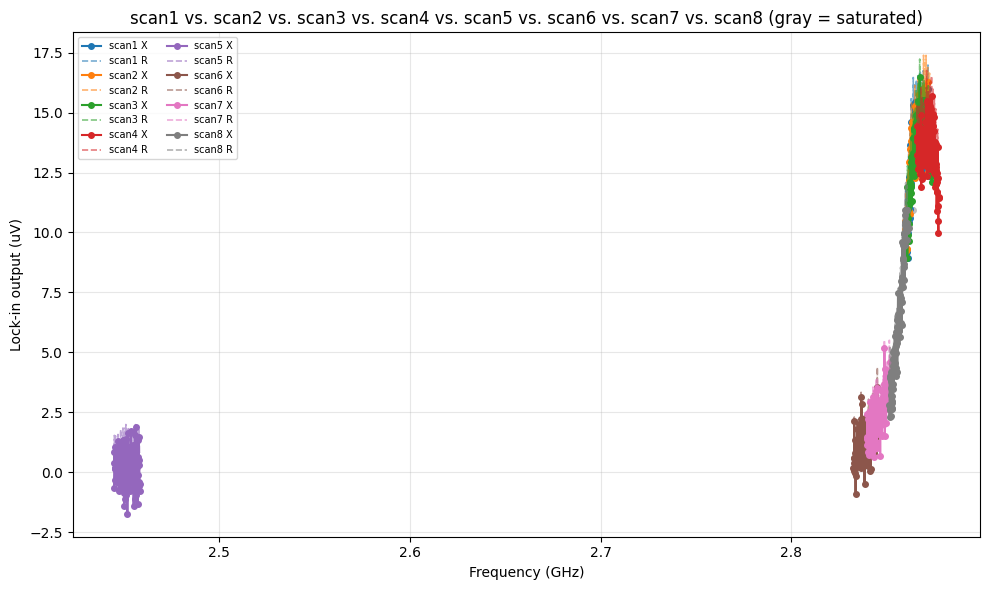

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, name in enumerate(RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs = d["freqs_ghz"]
    x_uv = d["x"] * 1e6
    r_uv = d["r"] * 1e6

    x_good = np.where(sat, np.nan, x_uv)
    r_good = np.where(sat, np.nan, r_uv)
    x_bad = np.where(sat, x_uv, np.nan)
    r_bad = np.where(sat, r_uv, np.nan)

    ax.plot(freqs, x_good, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(freqs, r_good, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")
    ax.plot(freqs, x_bad, "o", color="0.75", ms=4, zorder=1)
    ax.plot(freqs, r_bad, "--", color="0.75", lw=1.2, alpha=0.6, zorder=1)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(RUN_NAMES) + " (gray = saturated)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Combined fit: all scans except scan5, single Lorentzian

Pools every non-saturated point from all of `ZOOM_RUN_NAMES` into one dataset (sorted by frequency) and fits a single Lorentzian, instead of fitting each scan separately.

In [7]:
combined_freqs_mhz = np.concatenate([
    runs[name]["freqs_ghz"][~runs[name]["saturated"]] * 1e3
    for name in ZOOM_RUN_NAMES
])
combined_x_uv = np.concatenate([
    runs[name]["x"][~runs[name]["saturated"]] * 1e6
    for name in ZOOM_RUN_NAMES
])

order = np.argsort(combined_freqs_mhz)
combined_freqs_mhz = combined_freqs_mhz[order]
combined_x_uv = combined_x_uv[order]

print(f"{len(combined_freqs_mhz)} combined points, "
      f"{combined_freqs_mhz.min():.4f}-{combined_freqs_mhz.max():.4f} MHz")

baseline_guess = np.median(np.concatenate([combined_x_uv[:10], combined_x_uv[-10:]]))
dip_idx = np.argmin(combined_x_uv) if abs(combined_x_uv.min() - baseline_guess) > abs(combined_x_uv.max() - baseline_guess) \
    else np.argmax(combined_x_uv)
center_guess = combined_freqs_mhz[dip_idx]
amplitude_guess = baseline_guess - combined_x_uv[dip_idx]
span_mhz = combined_freqs_mhz.max() - combined_freqs_mhz.min()
fwhm_guess = span_mhz / 10

combined_popt, combined_pcov = curve_fit(
    lorentzian_dip, combined_freqs_mhz, combined_x_uv,
    p0=[baseline_guess, amplitude_guess, center_guess, fwhm_guess],
    maxfev=20000,
)
combined_perr = np.sqrt(np.diag(combined_pcov))
baseline_fit, amplitude_fit, center_fit, fwhm_fit = combined_popt

print(f"combined fit: baseline = {baseline_fit:.4f} +/- {combined_perr[0]:.4f} uV")
print(f"combined fit: amplitude = {amplitude_fit:.4f} +/- {combined_perr[1]:.4f} uV")
print(f"combined fit: center = {center_fit:.4f} +/- {combined_perr[2]:.4f} MHz")
print(f"combined fit: FWHM = {abs(fwhm_fit):.4f} +/- {combined_perr[3]:.4f} MHz")

864 combined points, 2832.6000-2877.3250 MHz
combined fit: baseline = -1.9442 +/- 0.1571 uV
combined fit: amplitude = -16.6479 +/- 0.1451 uV
combined fit: center = 2869.2129 +/- 0.0877 MHz
combined fit: FWHM = 27.9491 +/- 0.5351 MHz


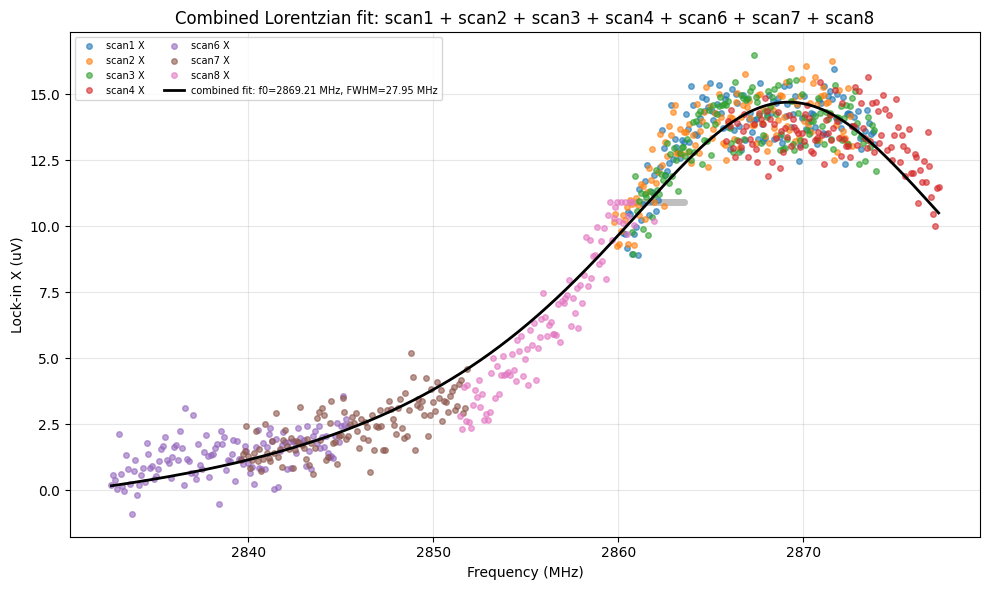

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(ZOOM_RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    sat = d["saturated"]
    freqs_mhz = d["freqs_ghz"] * 1e3
    x_uv = d["x"] * 1e6
    ax.plot(freqs_mhz[~sat], x_uv[~sat], "o", color=color, ms=4, alpha=0.6, label=f"{name} X")
    ax.plot(freqs_mhz[sat], x_uv[sat], "o", color="0.75", ms=4, zorder=1)

f_fine = np.linspace(combined_freqs_mhz.min(), combined_freqs_mhz.max(), 600)
ax.plot(f_fine, lorentzian_dip(f_fine, *combined_popt), "k-", lw=2,
        label=f"combined fit: f0={center_fit:.2f} MHz, FWHM={abs(fwhm_fit):.2f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("Combined Lorentzian fit: " + " + ".join(ZOOM_RUN_NAMES))
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: power comparison, powerstudy4 + powerstudy5 + powerstudy6 (X, mean +/- SEM)

`powerstudy5` covers a new, non-overlapping frequency segment (~2.8666-2.8795 GHz) from `powerstudy4`'s (~2.8522-2.8639 GHz) -- combined here per power level. Repeat count is auto-detected per run (not all power levels/segments have the same number of repeats completed yet). Plotted as individual points (no connecting line) with error bars = standard error of the mean across whatever repeats are available at each point.

In [9]:
import os

def mean_sem_for_run(run_path, prefix, tag):
    """Auto-detect how many repeats exist for prefix_tag in run_path,
    load them all, and return (freqs_hz, x_mean, x_sem, n_repeats).
    Skips any repeat whose length doesn't match the expected full-sweep
    length (from freqs_hz) -- a partial repeat (interlock trip or an
    overload give-up) is saved to disk by cmd_sweep_average() but should
    be excluded from averaging, same convention as the saved _avg_*.npy
    files use."""
    freqs_hz = np.load(f"{run_path}/{prefix}_{tag}_repeat0_freqs_hz.npy")
    expected_len = len(freqs_hz)
    reps = []
    r = 0
    n_skipped = 0
    while os.path.exists(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy"):
        x_rep = np.load(f"{run_path}/{prefix}_{tag}_repeat{r}_x.npy")
        if len(x_rep) == expected_len:
            reps.append(x_rep)
        else:
            n_skipped += 1
        r += 1
    if n_skipped:
        print(f"  ({prefix}_{tag}: skipped {n_skipped} partial repeat(s))")
    x_reps = np.stack(reps)
    x_mean = x_reps.mean(axis=0)
    n = len(reps)
    x_sem = x_reps.std(axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(x_mean)
    return freqs_hz, x_mean, x_sem, n


RUNS_TO_COMBINE = [
    (r"D:\cw_odmr_lock_in\powerstudy4", "powerstudy4"),
    (r"D:\cw_odmr_lock_in\powerstudy5", "powerstudy5"),
    (r"D:\cw_odmr_lock_in\powerstudy6", "powerstudy6"),
]
POWER_TAGS = {"0 dBm": "p0dBm", "-5 dBm": "pm5dBm", "-10 dBm": "pm10dBm"}

power_stats_combined = {}
for label, tag in POWER_TAGS.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_TO_COMBINE:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_combined[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy4 contributes 118 points, 5 repeats


0 dBm: powerstudy5 contributes 130 points, 5 repeats
0 dBm: powerstudy6 contributes 26 points, 5 repeats


-5 dBm: powerstudy4 contributes 118 points, 5 repeats
-5 dBm: powerstudy5 contributes 130 points, 5 repeats


  (powerstudy6_pm5dBm: skipped 4 partial repeat(s))
-5 dBm: powerstudy6 contributes 26 points, 1 repeats
-10 dBm: powerstudy4 contributes 118 points, 5 repeats


-10 dBm: powerstudy5 contributes 130 points, 5 repeats
-10 dBm: powerstudy6 contributes 23 points, 5 repeats


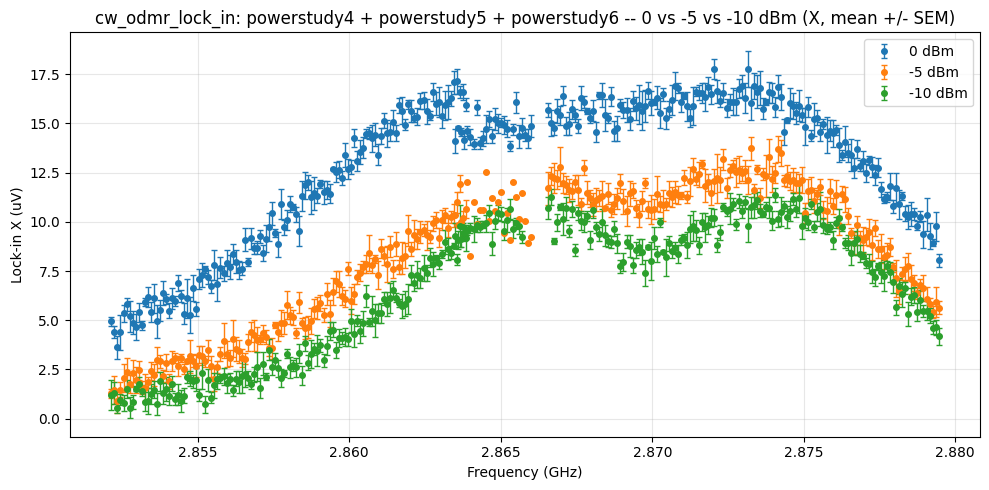

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, d in power_stats_combined.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy4 + powerstudy5 + powerstudy6 -- "
             "0 vs -5 vs -10 dBm (X, mean +/- SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerstudy8 + powerstudy9 -- all power levels

Combines `powerstudy8` (~2.8622-2.8773 GHz) and `powerstudy9` (~2.8513-2.8676 GHz) per power level -- the two segments partially overlap. Common power levels: 0, -5, -10, -15, -20 dBm (powerstudy8 also has -25 dBm, included on its own). Mean +/- SEM via `mean_sem_for_run()` (defined above), which already skips partial repeats.

In [11]:
RUNS_89 = [
    (r"D:\cw_odmr_lock_in\powerstudy8", "powerstudy8"),
    (r"D:\cw_odmr_lock_in\powerstudy9", "powerstudy9"),
]
POWER_TAGS_89 = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
    "-25 dBm": "pm25dBm",
}

power_stats_89 = {}
for label, tag in POWER_TAGS_89.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_89:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_89[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerstudy8 contributes 152 points, 25 repeats


-5 dBm: powerstudy8 contributes 152 points, 25 repeats


-10 dBm: powerstudy8 contributes 152 points, 25 repeats


-15 dBm: powerstudy8 contributes 152 points, 25 repeats


-20 dBm: powerstudy8 contributes 152 points, 25 repeats


-25 dBm: powerstudy8 contributes 152 points, 25 repeats


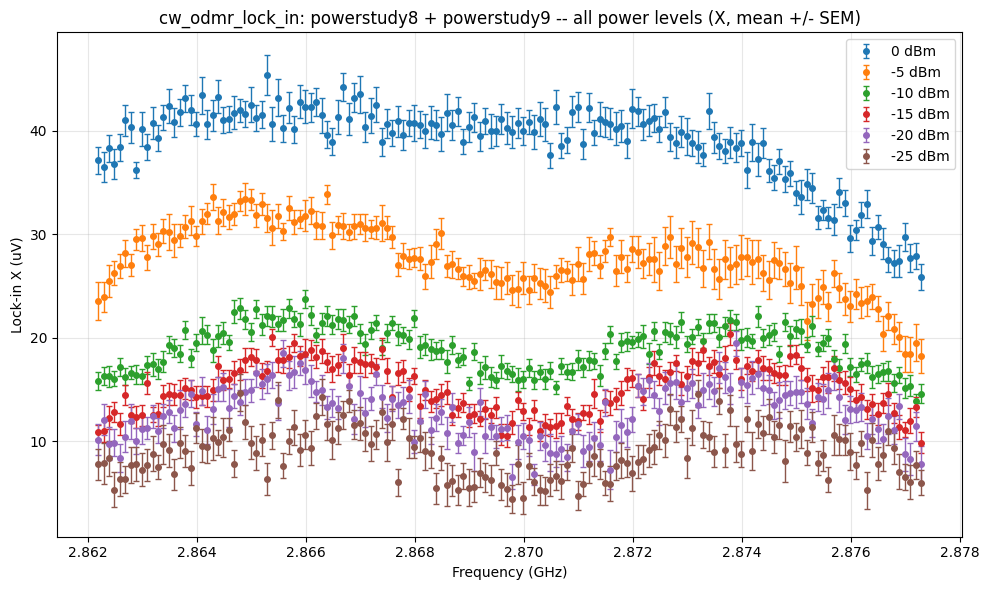

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_89.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: powerstudy8 + powerstudy9 -- "
             "all power levels (X, mean +/- SEM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: powerscan1 - powerscan8 -- all power levels

Combines `powerscan1` (~2.8677-2.8812 GHz), `powerscan2` (~2.8445-2.8565 GHz), `powerscan3` (~2.8521-2.8657 GHz, slightly overlapping `powerscan2`), `powerscan4` (~2.865-2.870 GHz, overlapping `powerscan1`), `powerscan5` (~2.880-2.885 GHz), `powerscan6` (~2.884-2.890 GHz, adjacent to `powerscan5`), `powerscan7` (~2.889-2.893 GHz, adjacent to `powerscan6`), and `powerscan8` (~2.892-2.895 GHz, adjacent/overlapping `powerscan7`) per power level -- same convention as the `powerstudy` combination sections above (`mean_sem_for_run()`, segments concatenated and sorted by frequency). Common power levels: 0, -5, -10, -15, -20 dBm. Only 1 repeat per run/power level, so error bars are all-zero.

In [17]:
RUNS_POWERSCAN = [
    (r"D:\cw_odmr_lock_in\powerscan1", "powerscan1"),
    (r"D:\cw_odmr_lock_in\powerscan2", "powerscan2"),
    (r"D:\cw_odmr_lock_in\powerscan3", "powerscan3"),
    (r"D:\cw_odmr_lock_in\powerscan4", "powerscan4"),
    (r"D:\cw_odmr_lock_in\powerscan5", "powerscan5"),
    (r"D:\cw_odmr_lock_in\powerscan6", "powerscan6"),
    (r"D:\cw_odmr_lock_in\powerscan7", "powerscan7"),
    (r"D:\cw_odmr_lock_in\powerscan8", "powerscan8"),
]
POWER_TAGS_POWERSCAN = {
    "0 dBm": "p0dBm",
    "-5 dBm": "pm5dBm",
    "-10 dBm": "pm10dBm",
    "-15 dBm": "pm15dBm",
    "-20 dBm": "pm20dBm",
}

power_stats_powerscan = {}
for label, tag in POWER_TAGS_POWERSCAN.items():
    freqs_list, mean_list, sem_list = [], [], []
    for run_path, prefix in RUNS_POWERSCAN:
        if not os.path.exists(f"{run_path}/{prefix}_{tag}_repeat0_x.npy"):
            continue
        freqs_hz, x_mean, x_sem, n = mean_sem_for_run(run_path, prefix, tag)
        freqs_list.append(freqs_hz)
        mean_list.append(x_mean)
        sem_list.append(x_sem)
        print(f"{label}: {prefix} contributes {len(freqs_hz)} points, {n} repeats")
    if not freqs_list:
        continue
    freqs_hz_all = np.concatenate(freqs_list)
    x_mean_all = np.concatenate(mean_list)
    x_sem_all = np.concatenate(sem_list)
    order = np.argsort(freqs_hz_all)
    power_stats_powerscan[label] = dict(
        freqs_ghz=freqs_hz_all[order] / 1e9,
        x_mean=x_mean_all[order],
        x_sem=x_sem_all[order],
    )

0 dBm: powerscan1 contributes 136 points, 1 repeats
0 dBm: powerscan2 contributes 121 points, 1 repeats
0 dBm: powerscan3 contributes 137 points, 1 repeats
0 dBm: powerscan4 contributes 51 points, 1 repeats


0 dBm: powerscan5 contributes 51 points, 1 repeats


0 dBm: powerscan6 contributes 61 points, 1 repeats


0 dBm: powerscan7 contributes 41 points, 1 repeats
0 dBm: powerscan8 contributes 31 points, 1 repeats


-5 dBm: powerscan1 contributes 136 points, 1 repeats
-5 dBm: powerscan2 contributes 121 points, 1 repeats
-5 dBm: powerscan3 contributes 137 points, 1 repeats
-5 dBm: powerscan4 contributes 51 points, 1 repeats
-5 dBm: powerscan5 contributes 51 points, 1 repeats


...

-10 dBm: powerscan2 contributes 121 points, 1 repeats
-10 dBm: powerscan3 contributes 137 points, 1 repeats
-10 dBm: powerscan4 contributes 51 points, 1 repeats
-10 dBm: powerscan5 contributes 51 points, 1 repeats
-10 dBm: powerscan6 contributes 61 points, 1 repeats


-10 dBm: powerscan7 contributes 41 points, 1 repeats
-10 dBm: powerscan8 contributes 31 points, 1 repeats
-15 dBm: powerscan1 contributes 136 points, 1 repeats
-15 dBm: powerscan2 contributes 121 points, 1 repeats
-15 dBm: powerscan3 contributes 137 points, 1 repeats
-15 dBm: powerscan4 contributes 51 points, 1 repeats


-15 dBm: powerscan5 contributes 51 points, 1 repeats
-15 dBm: powerscan6 contributes 61 points, 1 repeats
-15 dBm: powerscan7 contributes 41 points, 1 repeats
-15 dBm: powerscan8 contributes 31 points, 1 repeats


-20 dBm: powerscan1 contributes 136 points, 1 repeats
-20 dBm: powerscan2 contributes 121 points, 1 repeats
-20 dBm: powerscan3 contributes 137 points, 1 repeats
-20 dBm: powerscan4 contributes 51 points, 1 repeats


-20 dBm: powerscan5 contributes 51 points, 1 repeats
-20 dBm: powerscan6 contributes 61 points, 1 repeats
-20 dBm: powerscan7 contributes 41 points, 1 repeats
-20 dBm: powerscan8 contributes 31 points, 1 repeats


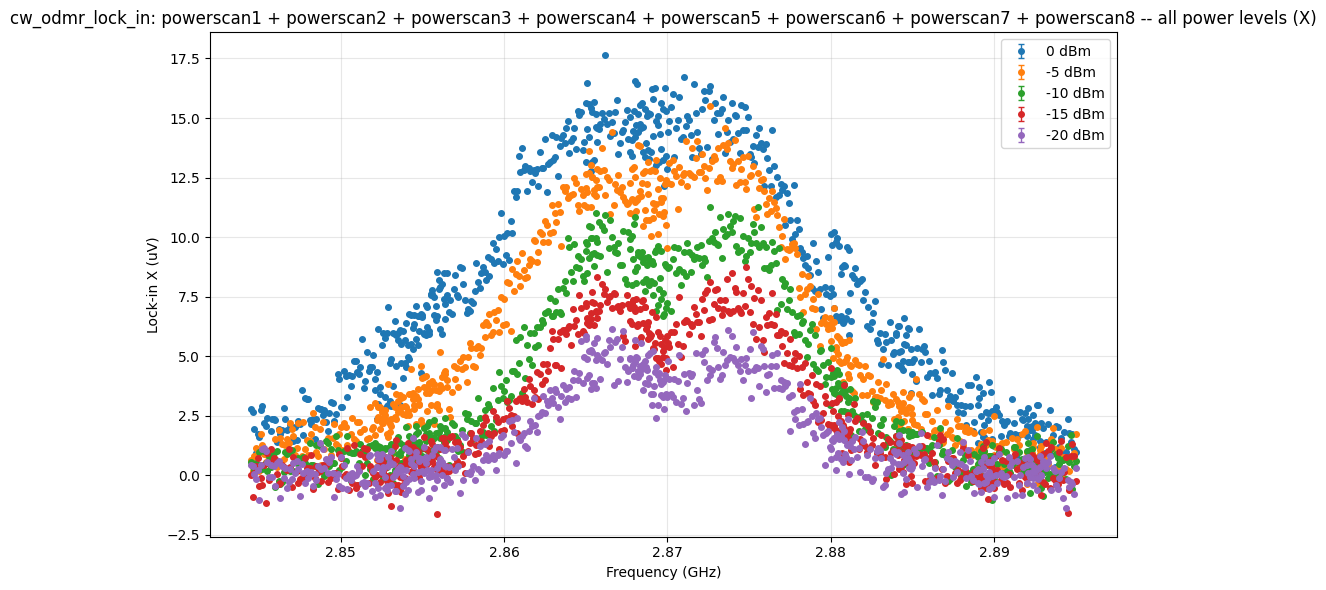

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

for label, d in power_stats_powerscan.items():
    ax.errorbar(d["freqs_ghz"], d["x_mean"] * 1e6, yerr=d["x_sem"] * 1e6,
                fmt="o", ms=4, capsize=2, lw=1, label=label)

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in X (uV)")
ax.set_title("cw_odmr_lock_in: " + " + ".join(prefix for _, prefix in RUNS_POWERSCAN) +
             " -- all power levels (X)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Static field, 1.5 A, ~dist from diamond, 0 dBm drive

`run`-style single-sweep results (same `_lockin_spectrum_*` file layout as `scan1-scan8` above) from `D:\cw_odmr_lock_in\static{1..5}` -- taken with the static-field coil (SPD1168X) on. Plotted on their own, both X and R.

In [19]:
STATIC_RUN_NAMES = ["static1", "static2", "static3", "static4", "static5"]

static_runs = {}
for name in STATIC_RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    static_runs[name] = dict(freqs_ghz=freqs_hz / 1e9, x=x, r=np.hypot(x, y))
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_hz.min()/1e9:.6f}-{freqs_hz.max()/1e9:.6f} GHz")

static1: 156 points, 2.827750-2.843250 GHz
static2: 138 points, 2.905500-2.919200 GHz


static3: 126 points, 2.838600-2.851100 GHz
static4: 142 points, 2.850175-2.864275 GHz
static5: 121 points, 2.864125-2.876125 GHz


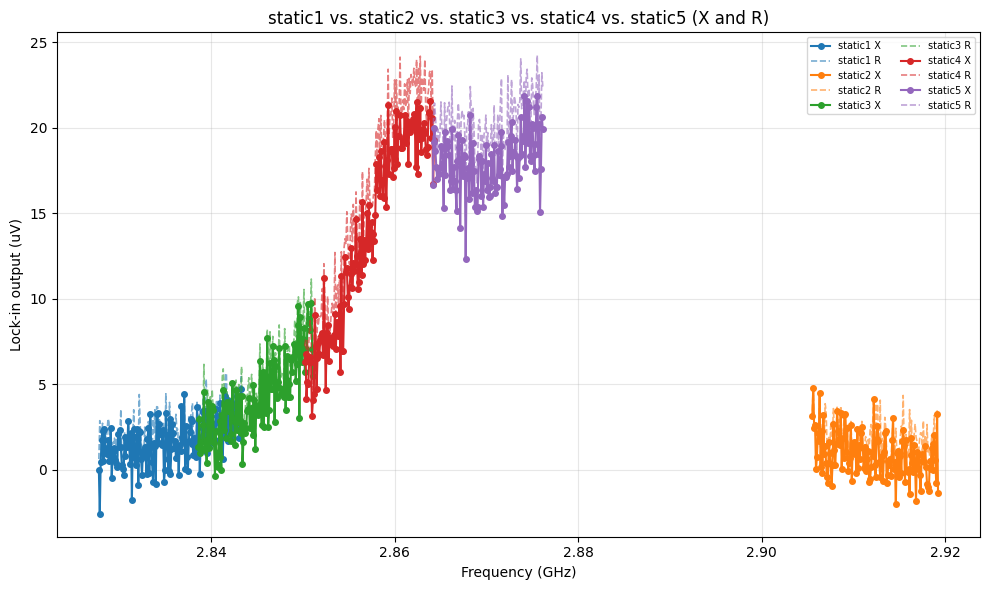

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(STATIC_RUN_NAMES):
    d = static_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(d["freqs_ghz"], d["r"] * 1e6, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(STATIC_RUN_NAMES) + " (X and R)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# cw_odmr_lock_in result: static_new1 vs static_new1_power_up (X and R)

Same `run`-style single-sweep layout as the static field runs above, from `D:\cw_odmr_lock_in\static_new1` and `D:\cw_odmr_lock_in\static_new1_power_up`. Plotted separately from the set above, both X and R.

In [21]:
STATIC_NEW_RUN_NAMES = ["static_new1", "static_new1_power_up"]

static_new_runs = {}
for name in STATIC_NEW_RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    static_new_runs[name] = dict(freqs_ghz=freqs_hz / 1e9, x=x, r=np.hypot(x, y))
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_hz.min()/1e9:.6f}-{freqs_hz.max()/1e9:.6f} GHz")

static_new1: 127 points, 2.867025-2.879625 GHz
static_new1_power_up: 130 points, 2.866875-2.879775 GHz


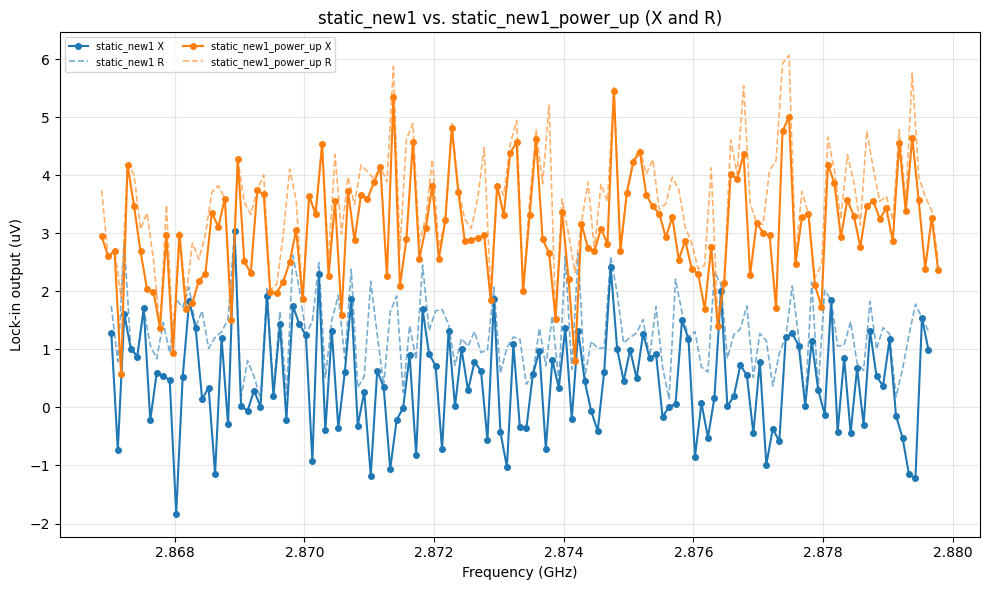

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, name in enumerate(STATIC_NEW_RUN_NAMES):
    d = static_new_runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(d["freqs_ghz"], d["r"] * 1e6, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(STATIC_NEW_RUN_NAMES) + " (X and R)")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()